<a href="https://colab.research.google.com/github/soumya-ranjan-000/RAG-Chatbot-Project/blob/main/Intro_to_rag_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Ingestion Pipeline**

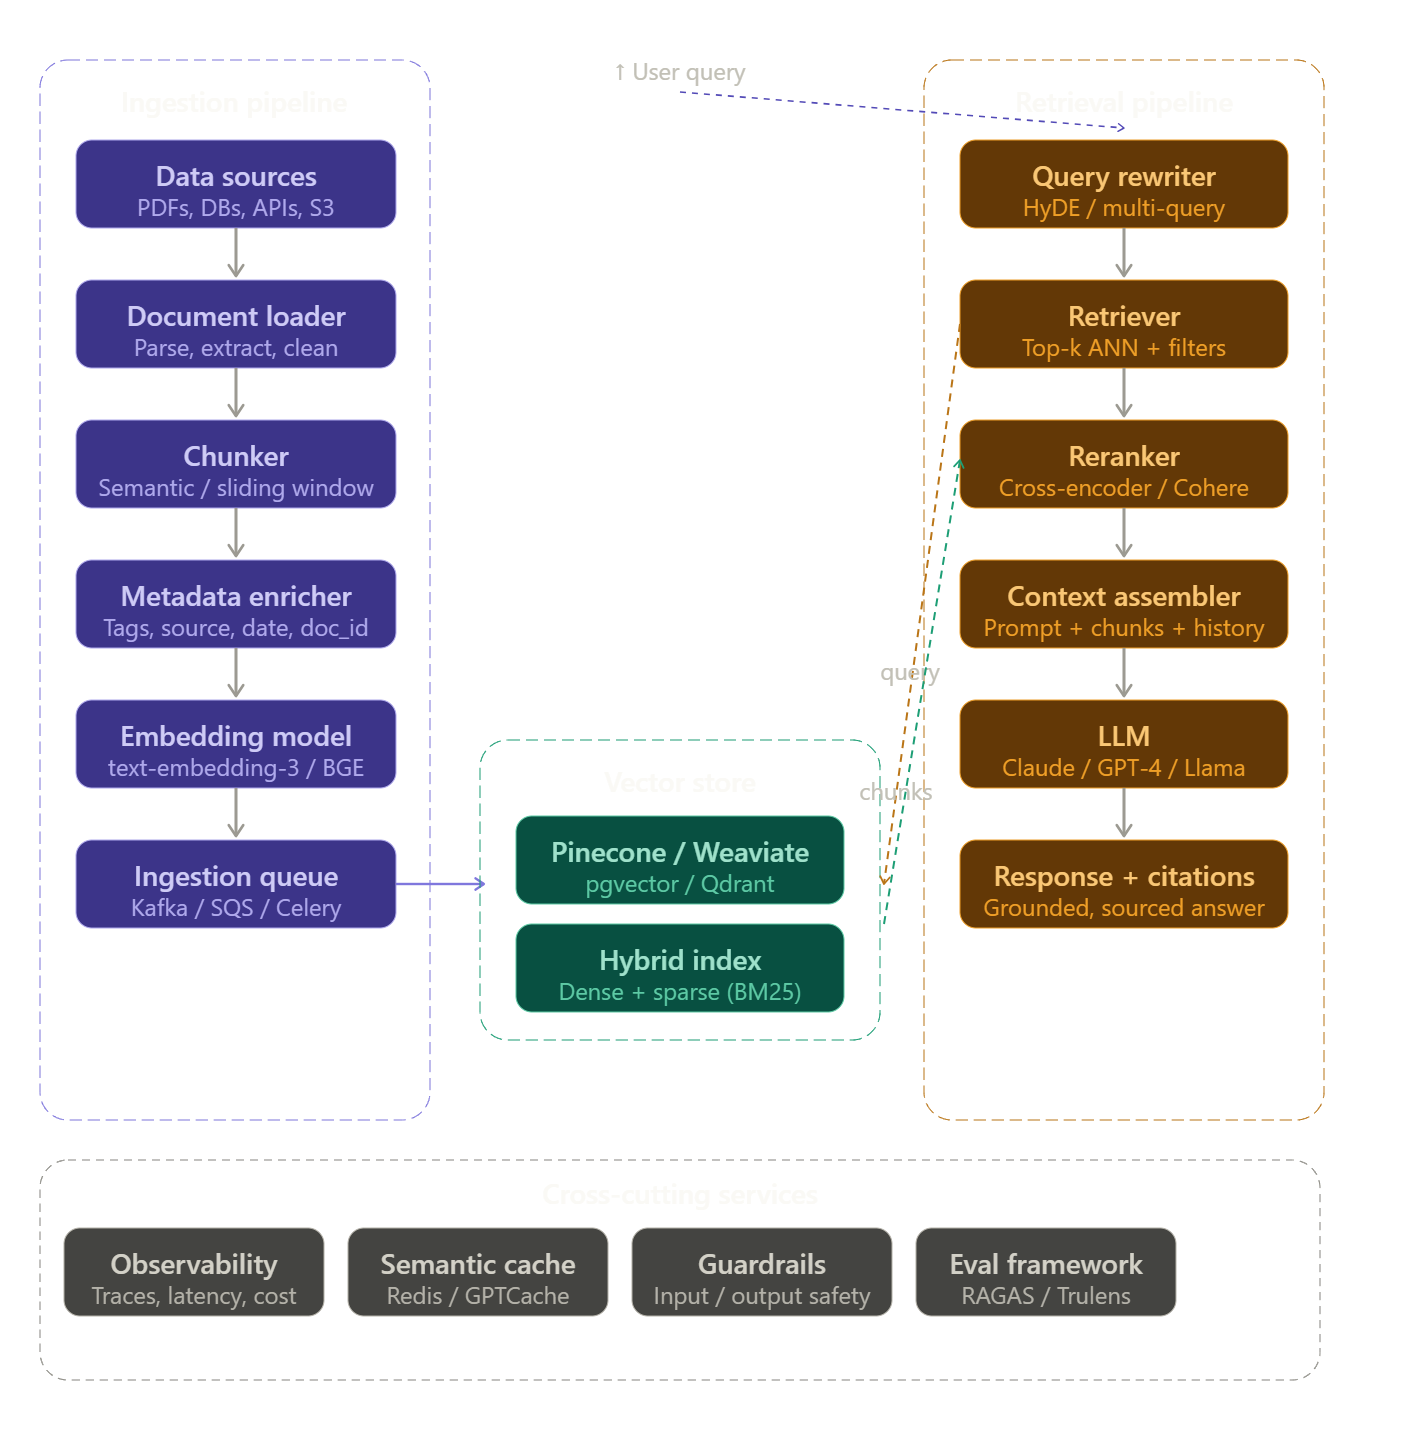

Install Dependencies

In [ ]:
# Install Python libraries
!pip install PyPDF2 python-docx pytesseract beautifulsoup4 pillow langchain_text_splitters

# Install the Tesseract OCR engine
!apt-get install tesseract-ocr

# Upgrade to latest versions of core RAG libraries
!pip install --upgrade chromadb langchain-chroma sentence-transformers
!pip install --upgrade numpy
!pip install umap-learn plotly

# Note: If you see an AttributeError related to numpy after this,
# please go to 'Runtime' -> 'Restart session' and run the cells again.
# Newer versions of chromadb (0.5.x+) are compatible with NumPy 2.0+

Download all company policy documents to the local folder

In [1]:
import gdown
import os

COMPANY_POLICY_DIR = "rag_docs"

# The folder ID from your specific link
folder_id = '1YPDpdBiBshI7fEyJ0oenQUcZO_guo708'
url = f'https://drive.google.com/drive/folders/{folder_id}'


# 2. Create the directory if it doesn't exist yet
if not os.path.exists(COMPANY_POLICY_DIR):
    os.makedirs(COMPANY_POLICY_DIR)
    # Use download_folder instead of download
    gdown.download_folder(url, output=COMPANY_POLICY_DIR, quiet=False, use_cookies=False)
else:
  print("Directory exists! Continue")

Directory exists! Continue


Methods to read a specific file from the folder

In [2]:
import PyPDF2
from docx import Document
from PIL import Image
import pytesseract

def read_file(file_name: str) -> str:
    file_path = os.path.join(COMPANY_POLICY_DIR, file_name)

    if not os.path.exists(file_path):
        return f"Error: File '{file_name}' not found."

    ext = os.path.splitext(file_name)[-1].lower()

    try:
        # 1. PDF Files
        if ext == '.pdf':
            text = ""
            with open(file_path, 'rb') as file:
                reader = PyPDF2.PdfReader(file)
                for page in reader.pages:
                    content = page.extract_text()
                    if content: text += content + "\n"
            return text.strip()

        # 2. Word Documents (.docx)
        elif ext == '.docx':
            doc = Document(file_path)
            return "\n".join([para.text for para in doc.paragraphs])

        # 3. Images (using OCR)
        elif ext in ['.png', '.jpg', '.jpeg', '.tiff']:
            return pytesseract.image_to_string(Image.open(file_path))

        # 4. HTML Files
        elif ext in ['.html', '.htm']:
            with open(file_path, 'r', encoding='utf-8') as file:
                from bs4 import BeautifulSoup
                soup = BeautifulSoup(file, 'html.parser')
                return soup.get_text(separator=' ')

        # 5. Standard Text/Markdown
        elif ext in ['.txt', '.md']:
            with open(file_path, 'r', encoding='utf-8') as file:
                return file.read().strip()

        else:
            return f"Skipping unsupported file type: {ext}"

    except Exception as e:
        return f"Error processing {file_name}: {str(e)}"

Test read_file method

In [3]:
read_file('google_code_of_conduct.pdf')

'Board\n&\nGovernance\nhttps://abc.xyz/investor/google-code-of-conduct/\nGoogle\nCode\nof\nConduct\nThe\nGoogle\nCode\nof\nConduct\nis\none\nof\nthe\nways\nwe\nput\nGoogle’ s\nvalues\ninto\npractice.\nIt’s\nbuilt\naround\nthe\nrecognition\nthat\neverything\nwe\ndo\nin\nconnection\nwith\nour\nwork\nat\nGoogle\nwill\nbe,\nand\nshould\nbe,\nmeasured\nagainst\nthe\nhighest\npossible\nstandards\nof\nethical\nbusiness\nconduct.\nWe\nset\nthe\nbar\nthat\nhigh\nfor\npractical\nas\nwell\nas\naspirational\nreasons:\nOur\ncommitment\nto\nthe\nhighest\nstandards\nhelps\nus\nhire\ngreat\npeople,\nbuild\ngreat\nproducts,\nand\nattract\nloyal\nusers.\nRespect\nfor\nour\nusers,\nfor\nthe\nopportunity ,\nand\nfor\neach\nother\nare\nfoundational\nto\nour\nsuccess,\nand\nare\nsomething\nwe\nneed\nto\nsupport\nevery\nday.\nSo\nplease\ndo\nread\nthe\nCode\nand\nGoogle’ s\nvalues,\nand\nfollow\nboth\nin\nspirit\nand\nletter ,\nalways\nbearing\nin\nmind\nthat\neach\nof\nus\nhas\na\npersonal\nresponsibility\n

### The Normalization Function:
#### Normalization is the process of cleaning this text so your RAG system sees clean, continuous sentences.

In [4]:
import re

def normalize_text(text: str) -> str:
    # 1. Replace multiple newlines with a single space
    # (Fixes the vertical 'Board\n&\nGovernance' issue)
    text = re.sub(r'\n+', ' ', text)

    # 2. Fix "broken" apostrophes like "Google' s" -> "Google's"
    text = re.sub(r"’\s+s", "’s", text)
    text = re.sub(r"'\s+s", "'s", text)

    # 3. Replace multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text)

    # 4. Remove extra whitespace from the start/end
    return text.strip()

lets, test the normalize_txt method

In [5]:
normalize_text(read_file('google_code_of_conduct.pdf'))

'Board & Governance https://abc.xyz/investor/google-code-of-conduct/ Google Code of Conduct The Google Code of Conduct is one of the ways we put Google’s values into practice. It’s built around the recognition that everything we do in connection with our work at Google will be, and should be, measured against the highest possible standards of ethical business conduct. We set the bar that high for practical as well as aspirational reasons: Our commitment to the highest standards helps us hire great people, build great products, and attract loyal users. Respect for our users, for the opportunity , and for each other are foundational to our success, and are something we need to support every day. So please do read the Code and Google’s values, and follow both in spirit and letter , always bearing in mind that each of us has a personal responsibility to incorporate, and to encourage other Googlers to incorporate, the principles of the Code and values into our work. And if you have a questi

### Metadata:
#### For a professional RAG pipeline, you shouldn't just return a string. You should return a dictionary or a Class object that keeps the filename attached to the text.

In [6]:
def get_rag_document(file_name: str):
    content = normalize_text(read_file(file_name))
    return {
        "content": content,
        "metadata": {
            "source": file_name,
            "type": os.path.splitext(file_name)[-1]
        }
    }

Lets test it

In [7]:
doc_obj = get_rag_document('google_code_of_conduct.pdf')
print(f"Source: {doc_obj['metadata']['source']}")
print(f"Content: {doc_obj['content'][:150]}...")

Source: google_code_of_conduct.pdf
Content: Board & Governance https://abc.xyz/investor/google-code-of-conduct/ Google Code of Conduct The Google Code of Conduct is one of the ways we put Google...


Great! Now that we have a Document Object containing cleaned text and metadata, we can move to the Chunking stage.

In a RAG pipeline, we don't just split text randomly. We use a Recursive Character Text Splitter. It tries to split by double newlines (paragraphs), then single newlines (sentences), and finally spaces (words). This keeps related information together in the same chunk.

1. The Chunking Logic
We will create a function that takes your doc_obj and returns a list of smaller "Chunk" objects.

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def create_chunks(doc_obj: dict, chunk_size: int = 1000, chunk_overlap: int = 100):
    # Initialize the splitter
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
    )

    # Split the content
    text_chunks = text_splitter.split_text(doc_obj['content'])

    # Package chunks with their original metadata
    final_chunks = []
    for i, chunk in enumerate(text_chunks):
        final_chunks.append({
            "chunk_id": i,
            "content": chunk,
            "metadata": {
                **doc_obj['metadata'],
                "chunk_index": i
            }
        })

    return final_chunks

In [22]:
create_chunks(doc_obj)

[{'chunk_id': 0,
  'content': 'Board & Governance https://abc.xyz/investor/google-code-of-conduct/ Google Code of Conduct The Google Code of Conduct is one of the ways we put Google’s values into practice. It’s built around the recognition that everything we do in connection with our work at Google will be, and should be, measured against the highest possible standards of ethical business conduct. We set the bar that high for practical as well as aspirational reasons: Our commitment to the highest standards helps us hire great people, build great products, and attract loyal users. Respect for our users, for the opportunity , and for each other are foundational to our success, and are something we need to support every day. So please do read the Code and Google’s values, and follow both in spirit and letter , always bearing in mind that each of us has a personal responsibility to incorporate, and to encourage other Googlers to incorporate, the principles of the Code and values into our 

# Metadata Enrichment

In [9]:
from datetime import datetime
import uuid

# A simple mapping for tags/categories based on file keywords
category_mapping = {
    "google": {"category": "Ethics", "tags": ["Big Tech", "Conduct"]},
    "apple": {"category": "Supply Chain", "tags": ["Sustainability", "Human Rights"]},
    "boeing": {"category": "Safety", "tags": ["Guidelines", "Aerospace"]},
    "ibm": {"category": "Business Ethics", "tags": ["Guidelines", "Corporate"]}
}

def get_enriched_rag_document(file_name: str):
    # 1. Generate a unique Document ID (not just chunk ID)
    # This helps if you ever want to delete all chunks related to one specific file
    document_id = str(uuid.uuid4())[:8]

    # 2. Get basic file info
    content = normalize_text(read_file(file_name))
    file_ext = os.path.splitext(file_name)[-1]

    # 3. Determine Category and Tags
    info = category_mapping.get(file_name.split('_')[0].lower(),
                                {"category": "General", "tags": ["Policy"]})

    return {
        "content": content,
        "metadata": {
            "source": file_name,
            "document_id": document_id,
            "type": file_ext,
            "category": info["category"],
            "tags": info["tags"],
            "ingestion_date": datetime.now().strftime("%Y-%m-%d"),
            "char_count": len(content)
        }
    }

# Processing the Whole Folder
### Now, let's tie everything together. This loop will look inside your rag_docs folder, read every file, normalize it, and break it into chunks.

In [10]:
all_processed_chunks = []
global_id_counter = 0  # <--- Start a global counter here

# Loop through every file in your downloaded folder
for file_name in os.listdir(COMPANY_POLICY_DIR):
    print(f"Processing: {file_name}...")

    # 1. Read & Normalize & Wrap in Metadata
    # doc_obj = get_rag_document(file_name)
    doc_obj = get_enriched_rag_document(file_name)


    # Skip if there was an error reading
    if "Error" in doc_obj['content']:
        print(f"Skipped {file_name} due to error.")
        continue

    # 2. Create chunks
    file_chunks = create_chunks(doc_obj)

    for chunk in file_chunks:
      chunk['chunk_id'] = global_id_counter
      chunk['metadata']['chunk_index']=global_id_counter
      global_id_counter+=1

    # 3. Add to our master list
    all_processed_chunks.extend(file_chunks)

print(f"\n✅ Total chunks created: {len(all_processed_chunks)}")

Processing: accenture_code_of_business_ethics.pdf...
Processing: apple_supplier_code_of_conduct.pdf...
Processing: boeing_conduct_guidelines.pdf...
Processing: chevron_ethics_code.pdf...
Processing: google_code_of_conduct.pdf...
Processing: ibm_business_conduct_guidelines.pdf...
Processing: walmart_code_of_conduct.pdf...

✅ Total chunks created: 853


Test a chunk

In [11]:
all_processed_chunks[0]

{'chunk_id': 0,
 'content': 'Welcome to the Y our guide to responsible behavior, every dayCode of Business Ethics Copyright © 2022 Accenture. All rights reserved. COBE2Contents Introduction Our Code Six Fundamental Behaviors Our Code of Business Ethics is organized under 6 fundamental behaviors that apply to every one of us, every day: About the Code 4 Making G ood Decisions 7 How to Raise Concerns 8 Make Your Conduct Count 10 Comply with Laws 19 Deliv er for Our Clients 34 Pr otect People, Information and Our Business 36 Run Our Business Responsibly 44 Be a G ood Corporate Citizen 50 Copyright © 2022 Accenture. All rights reserved. COBE3About the Code Putting Integrity Into Action Welcome to the Accenture Code of Business Ethics At Accenture, we care deeply about doing the right thing. We share a commitment to operating with the highest ethical standards and making a positive difference in everything we do. It’s part of our culture. It’s who we are. Our Code of Business Ethics is more

# Embeddings

In [14]:
import dotenv
dotenv.load_dotenv()

True

2. The Embedding Logic

  We will use a popular, lightweight model called all-MiniLM-L6-v2. It's fast and perfect for policy documents.

In [15]:
from sentence_transformers import SentenceTransformer

# 1. Load the model (this will download it the first time)
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Extract just the text content from your list of chunks
chunk_texts = [chunk['content'] for chunk in all_processed_chunks]

# 3. Generate the embeddings (the actual math)
print(f"Generating embeddings for {len(chunk_texts)} chunks... This may take a moment.")
embeddings = model.encode(chunk_texts, show_progress_bar=True)

# 4. Attach the embeddings back to your chunk objects
for i, chunk in enumerate(all_processed_chunks):
    chunk['embedding'] = embeddings[i]

print("\n✅ Embeddings generated and synced with chunk_ids!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Generating embeddings for 853 chunks... This may take a moment.


Batches:   0%|          | 0/27 [00:00<?, ?it/s]


✅ Embeddings generated and synced with chunk_ids!


In [16]:
all_processed_chunks[134]

{'chunk_id': 134,
 'content': 'identify, assess, and minimize risks related to anti-Harassment and abuse. Operational Practices Supplier shall ensure that all Workers are treated with respect and dignity. No form of Harassment or abuse shall be tolerated at the Workplace , including but not limited to physical Harassment, Psychological Harassment, Sexual Harassment, or Verbal Harassment. 2.1 Workplace discipline Supplier shall have written disciplinary rules, procedures and practices that embody a system of Progressive Discipline . The disciplinary system shall be applied in a fair and nondiscriminatory manner and include a management review by an objective party senior to the manager who imposed the disciplinary action. Worker Any person, regardless of nationality or country of origin, who is employed directly or via a third party, to work at Supplier’s facility. Workplace A physical place in which any of the following occur: • Workers conduct work or frequently enter for business. Em

3. Verification: What does an embedding look like?

In [18]:
# Check the embedding for the chunk you tested earlier (ID 310)
chunk = all_processed_chunks[300]
sample_vector = chunk['embedding']

print(f"Chunk ID: {chunk['chunk_id']}")
print(f"Vector Dimensions: {len(sample_vector)}") # Should be 384 for this model
print(f"First 5 numbers of the vector: {sample_vector[:5]}")
print(f'Metadata: {chunk["metadata"]}')

Chunk ID: 300
Vector Dimensions: 384
First 5 numbers of the vector: [-0.05673268  0.03661435  0.05018226 -0.03760371  0.02442562]
Metadata: {'source': 'apple_supplier_code_of_conduct.pdf', 'document_id': '295251b5', 'type': '.pdf', 'category': 'Supply Chain', 'tags': ['Sustainability', 'Human Rights'], 'ingestion_date': '2026-05-03', 'char_count': 337597, 'chunk_index': 300}


# VectorStore:
lets push these enriched chunks into ChromaDB



1. Install ChromaDB
First, install the client. We will also install langchain-chroma to make the integration with your existing all-processed_chunks smoother.

2. Initialize and Push Chunks
We will use your all_processed_chunks list. Note that ChromaDB can handle the embedding generation itself, but since you already generated them (saving us compute time/API calls), we will pass them in directly.

In [19]:
from google.colab import drive; drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [20]:
# This error typically arises from an incompatibility between chromadb and opentelemetry versions.
# We'll explicitly install compatible versions before importing chromadb.
# NOTE: If this fix doesn't work, consider restarting your Colab runtime (Runtime -> Restart runtime)
# and then running all cells again, especially the installation cells, in order.

import chromadb
from chromadb.config import Settings
import os

PROJECT_ROOT = os.getcwd()

# 1. Define where to save the database (Google Drive is best for persistence)
# If you haven't mounted drive: from google.colab import drive; drive.mount('/content/drive')
# CHROMA_PATH = "/content/drive/MyDrive/Projects/rag/policy_vector_db"
CHROMA_PATH = os.path.join(PROJECT_ROOT, "rag", "policy_vector_db")

print(f"Your database will be saved at: {CHROMA_PATH}")

# 2. Initialize the Chroma Client
client = chromadb.PersistentClient(path=CHROMA_PATH)

# 3. Create (or get) a collection
# We use 'cosine' similarity because it works best with the MiniLM model you used
collection = client.get_or_create_collection(name="company_policies", metadata={"hnsw:space": "cosine"})

# 4. Prepare data for batch upload
# Chroma expects lists of IDs, Embeddings, Metadata, and Documents
ids = [str(c['chunk_id']) for c in all_processed_chunks]
embeddings = [c['embedding'].tolist() for c in all_processed_chunks] # Convert numpy to list
metadatas = [c['metadata'] for c in all_processed_chunks]
documents = [c['content'] for c in all_processed_chunks]

# 5. Push to ChromaDB
# We upload in batches to avoid memory issues
batch_size = 100
for i in range(0, len(ids), batch_size):
    collection.add(
        ids=ids[i:i + batch_size],
        embeddings=embeddings[i:i + batch_size],
        metadatas=metadatas[i:i + batch_size],
        documents=documents[i:i + batch_size]
    )

print(f"✅ Successfully pushed {collection.count()} chunks to ChromaDB at {CHROMA_PATH}")

Your database will be saved at: d:\RAG Chatbot Project\proof-of-concepts\rag\policy_vector_db
✅ Successfully pushed 853 chunks to ChromaDB at d:\RAG Chatbot Project\proof-of-concepts\rag\policy_vector_db


## Quick Test:

### Perform a Retrieval
## Run this to see if the database can find a relevant policy:

In [21]:
# 1. Your query
query_text = "What is the policy regarding gifts and entertainment?"

# 2. Turn query into an embedding using your existing 'model'
query_embedding = model.encode(query_text).tolist()

# 3. Query the DB for the top 3 matches
results = collection.query(
    query_embeddings=[query_embedding],
    n_results=3
)

# 4. Display results
for i in range(len(results['documents'][0])):
    print(f"\n--- Result {i+1} (Source: {results['metadatas'][0][i]['source']}) ---")
    print(f"Content: {results['documents'][0][i][:200]}...")


--- Result 1 (Source: accenture_code_of_business_ethics.pdf) ---
Content: whether or not it is actually accepted or a benefit is received. Example Examples of “anything of value”: •Gif ts or gift baskets •Me als or drinks •Ent ertainment such as theater and sports tickets •...

--- Result 2 (Source: google_code_of_conduct.pdf) ---
Content: This not only includes traditional gifts, but also things like meals, travel, political or charitable contributions, and job offers for government officials’ relatives. Never give gifts to thank gover...

--- Result 3 (Source: accenture_code_of_business_ethics.pdf) ---
Content: questions is “yes”, the gift, meal, entertainment or travel is likely inappropriate.How do you determine if a gift, meal, entertainment or travel is appropriate? Ask:• W ould it cause any embarrassmen...


In [ ]:
results

{'ids': [['181', '45', '182']],
 'embeddings': None,
 'documents': [['whether or not it is actually accepted or a benefit is received. Example Examples of “anything of value”: •Gif ts or gift baskets •Me als or drinks •Ent ertainment such as theater and sports tickets •Client tr avel expenses •A ccenture-branded items •In vitations to marketing events •Int angibles such as: - P ersonal favors - L oans - Pr eferential treatment in connection with employment and internshipsSix Fundamental Behaviors | Comply with Laws Do not give inappropriate gifts, meals, entertainment or travel Under anticorruption laws, it is illegal to offer or give gifts, meals, entertainment or travel if done with a corrupt intention. A corrupt intention means that the goal in giving the gift, meal, entertainment or travel is to influence someone to misuse their position in order to benefit Accenture. Copyright © 2022 Accenture. All rights reserved. COBE21 If the answer to any of these questions is “yes”, the gift,

# Visualizing a vector database

Visualizing a vector database is one of the most exciting ways to actually see how RAG works. Since your embeddings (all-MiniLM-L6-v2) have 384 dimensions, we can't plot them directly. We have to use a technique called Dimensionality Reduction to squash those 384 dimensions down to 2D or 3D so our human eyes can understand them.

The industry standard for this is UMAP (Uniform Manifold Approximation and Projection). It groups similar concepts together in visual clusters. We will pair it with Plotly so you can hover over the dots in Colab and read the text!

In [28]:
import os
import umap
import chromadb
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

PROJECT_ROOT = os.getcwd()
CHROMA_PATH = os.path.join(PROJECT_ROOT, "rag", "policy_vector_db")

# 1. SETUP & RE-CONNECT
# CHROMA_PATH = "/content/drive/MyDrive/Projects/rag/policy_vector_db"
COLLECTION_NAME = "company_policies"
MODEL_NAME = 'all-MiniLM-L6-v2'

model = SentenceTransformer(MODEL_NAME)
client = chromadb.PersistentClient(path=CHROMA_PATH)
collection = client.get_collection(name=COLLECTION_NAME)

# 2. FETCH DATA
all_data = collection.get(include=["embeddings", "metadatas", "documents"])
all_embeddings = np.array(all_data['embeddings'])
all_ids = all_data['ids']

# 3. COMPUTE 2D (UMAP)
print("Reducing dimensions for visualization...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
projections = reducer.fit_transform(all_embeddings)

def visualize_vector_search(query_text):
    """
    Takes a string query, searches the ChromaDB collection,
    and draws a 2D map highlighting the results.
    """
    # 1. Embed the user query
    query_emb = model.encode(query_text).tolist()

    # 2. Search the collection for the top 5 matches
    results = collection.query(query_embeddings=[query_emb], n_results=5)
    highlight_ids = results['ids'][0]

    # 3. Create the Plot
    plt.figure(figsize=(12, 8), facecolor='#111111')
    ax = plt.gca()
    ax.set_facecolor('#111111')

    # Identify which points to highlight
    is_highlight = np.array([tid in highlight_ids for tid in all_ids])

    # Draw background galaxy (Gray)
    plt.scatter(
        projections[~is_highlight, 0],
        projections[~is_highlight, 1],
        c='gray', alpha=0.2, s=30, label='Library Chunks'
    )

    # Draw search results (Red)
    plt.scatter(
        projections[is_highlight, 0],
        projections[is_highlight, 1],
        c='red', alpha=1.0, s=180, edgecolors='white', linewidth=1.5, label='Search Results'
    )

    plt.title(f"Vector Space Highlights: '{query_text}'", color='white', fontsize=14, pad=20)
    plt.legend(facecolor='#222222', labelcolor='white', loc='upper right')
    plt.axis('off')
    plt.show()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Reducing dimensions for visualization...


d:\RAG Chatbot Project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Query: What is the policy regarding gifts and entertainment?

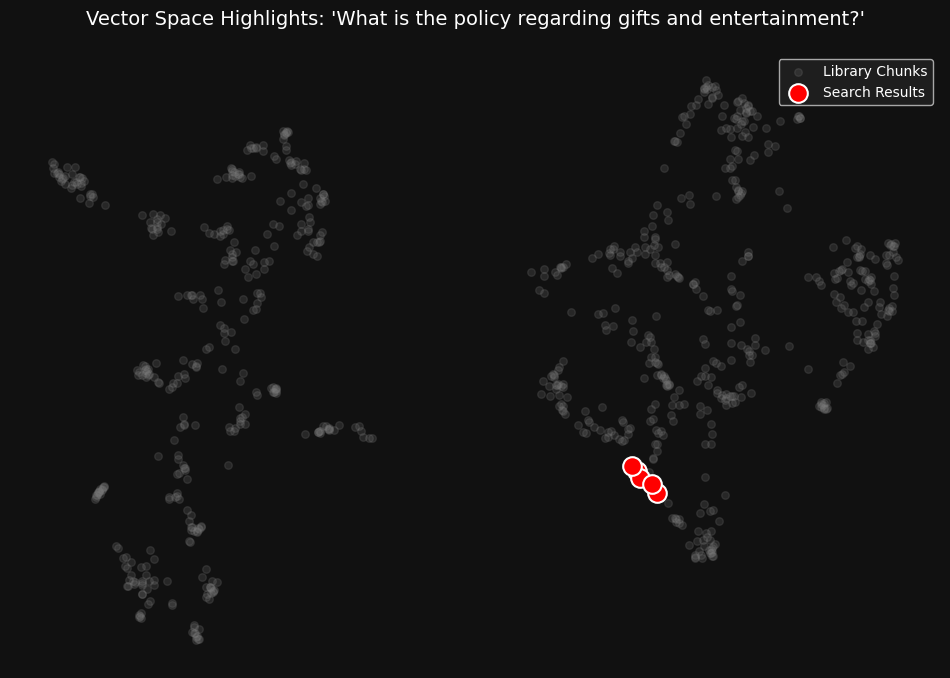

In [29]:
visualize_vector_search("What is the policy regarding gifts and entertainment?")

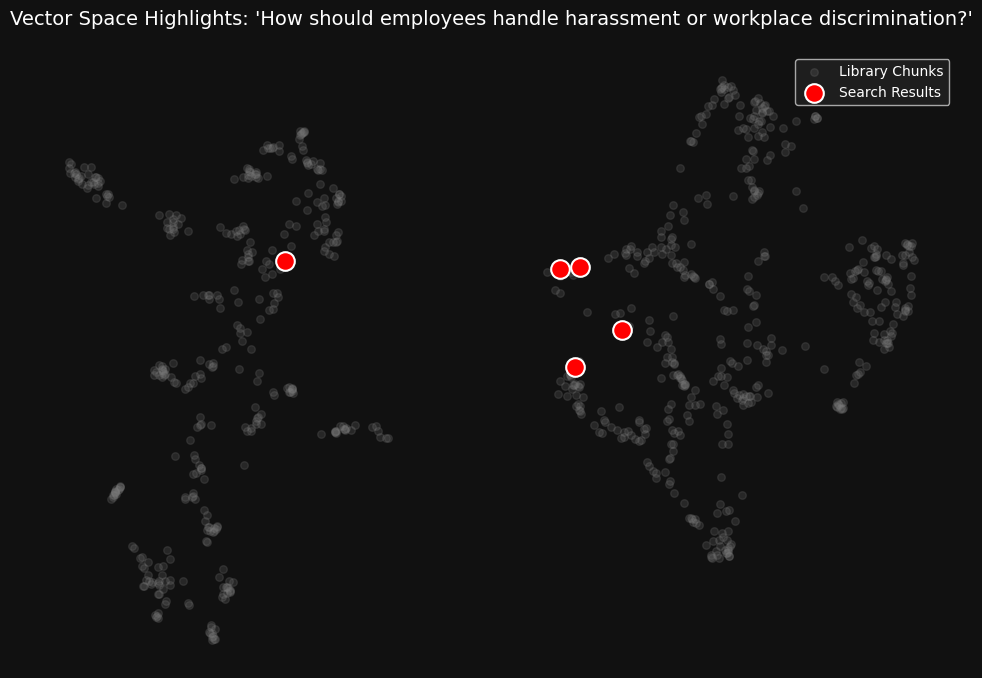

In [24]:
visualize_vector_search("How should employees handle harassment or workplace discrimination?")

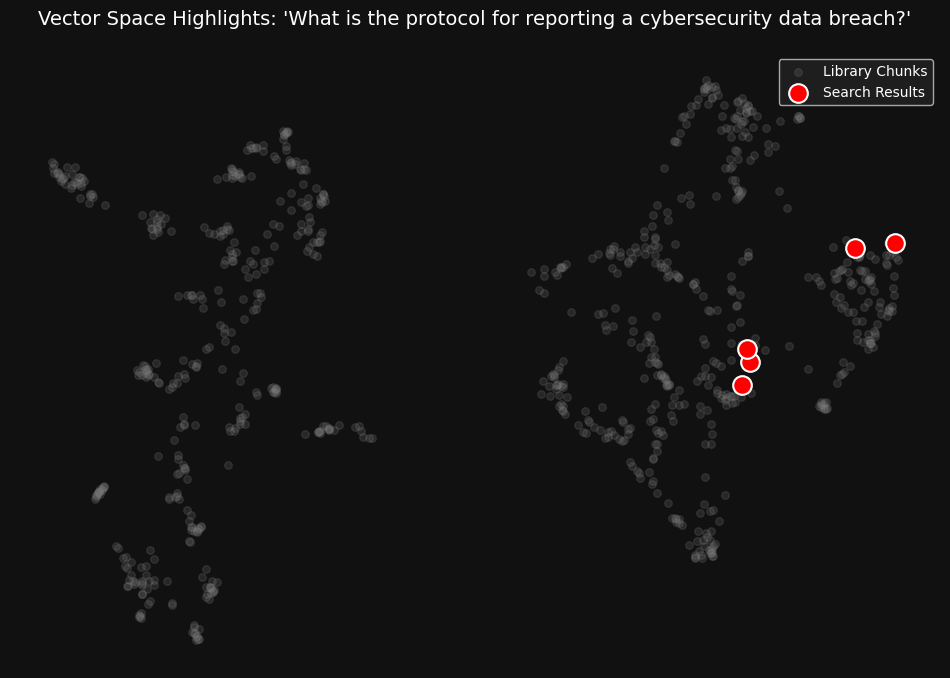

In [25]:
visualize_vector_search("What is the protocol for reporting a cybersecurity data breach?")

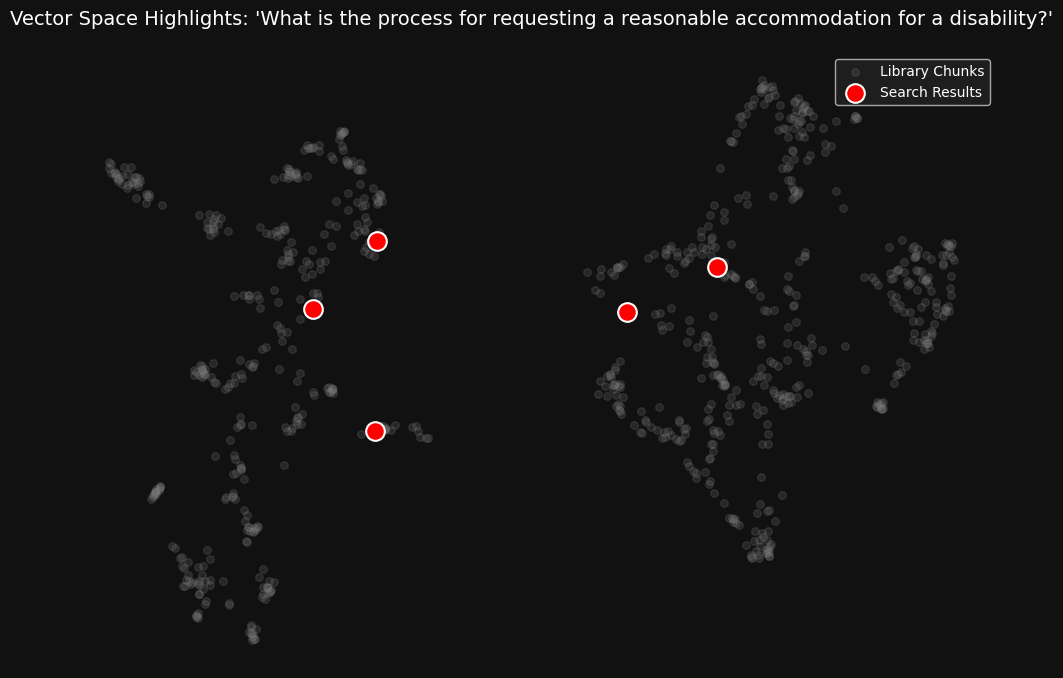

In [ ]:
visualize_vector_search("What is the process for requesting a reasonable accommodation for a disability?")

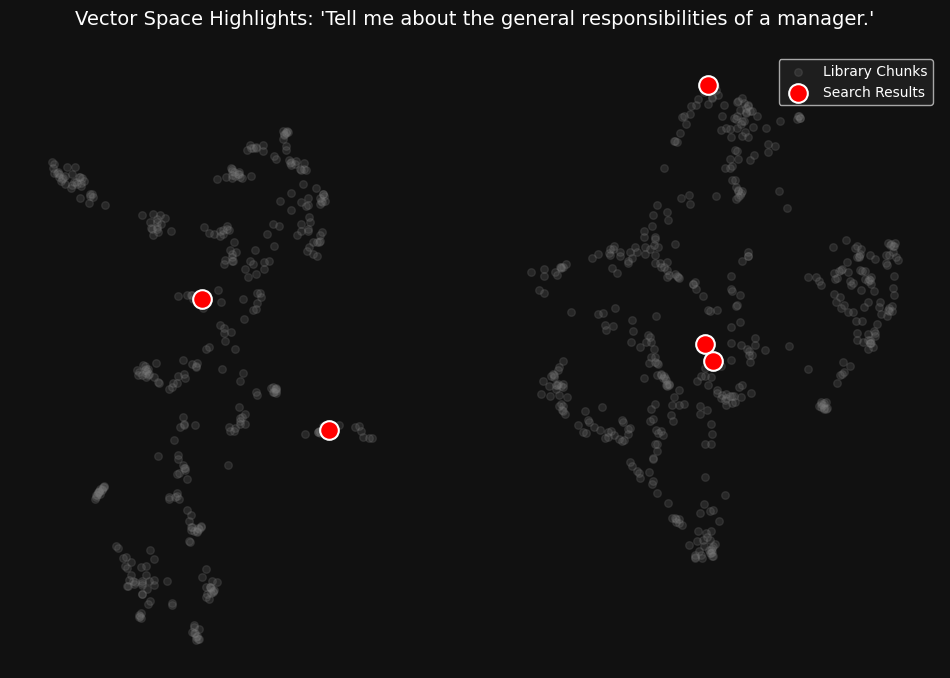

In [27]:
visualize_vector_search("Tell me about the general responsibilities of a manager.")